# Birnbaum-Saunders (Fatigue Life) Distribution

The **Birnbaum-Saunders distribution** was derived from a model of crack growth in materials under cyclic stress. It is used in **fatigue life analysis** — modeling the number of cycles to failure when cracks accumulate from repeated loading.

| Property | Value |
|---|---|
| **Parameters** | $\gamma$ (shape), $\beta$ (scale), $\mu$ (location) |
| **Support** | $(\mu, +\infty)$ |
| **Mean** | $\mu + \beta(1 + \gamma^2/2)$ |
| **Std Dev** | $\beta \cdot \gamma \cdot \sqrt{1 + 5\gamma^2/4}$ |
| **Skewness** | Right-skewed (increases with $\gamma$) |
| **Relationship** | Related to Inverse Gaussian and Lognormal |
| **Use cases** | Fatigue life, crack propagation, material strength, reliability |
| **Estimation** | MLE (no closed form — numerical optimisation) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Birnbaum-Saunders Distribution

### Panel 1 — PDF: Shape $\gamma$ Controls Tail Heaviness
Each curve shows the **PDF** of the Fatigue Life (Birnbaum-Saunders) distribution for different shape values $\gamma$. Small $\gamma$ gives a narrow, nearly symmetric distribution; large $\gamma$ produces a heavy right tail representing high variability in cycles to failure.

### Panel 2 — CDF
The **CDF** shows how the probability of failure accumulates with increasing cycles. Larger $\gamma$ shifts the curve right and makes it more gradual, indicating greater uncertainty in the time to failure.

### Panel 3 — MLE Fit to Simulated Fatigue Data
A histogram of 300 simulated fatigue-life cycles is overlaid with the true PDF (grey dashed) and the MLE-fitted PDF (blue solid). The fitted curve closely matches the generating distribution, demonstrating MLE accuracy.


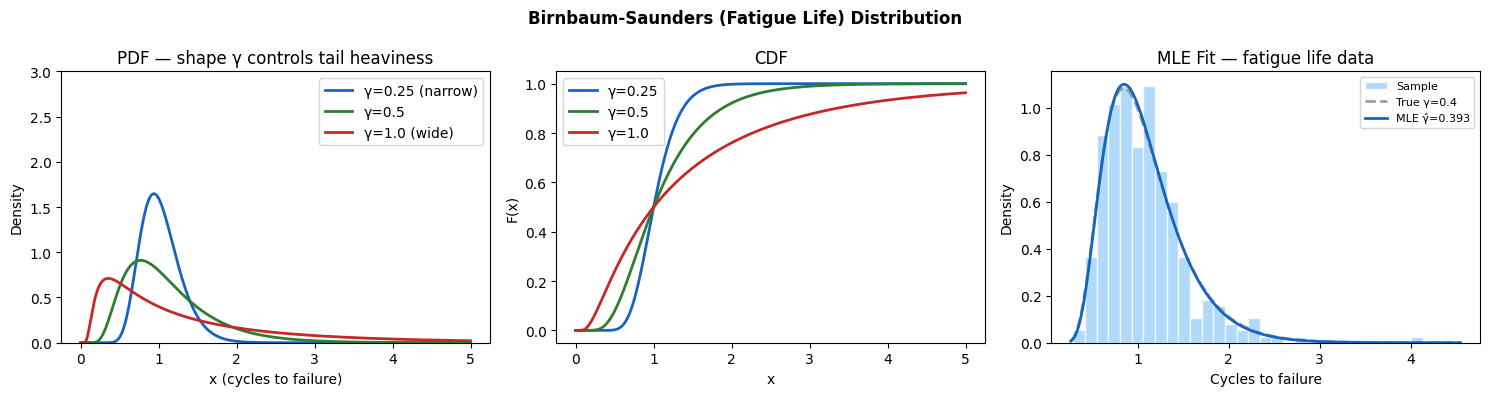

True: γ=0.4, β=1.0
MLE:  γ̂=0.393, β̂=0.999


In [2]:
# scipy implements Birnbaum-Saunders as 'fatiguelife'
x = np.linspace(0.001, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Birnbaum-Saunders (Fatigue Life) Distribution', fontsize=12, fontweight='bold')

# PDF for varying shape γ (scipy: c=gamma)
for gamma, color, label in [(0.25, '#1565C0', 'γ=0.25 (narrow)'),
                              (0.5,  '#2E7D32', 'γ=0.5'),
                              (1.0,  '#C62828', 'γ=1.0 (wide)')]:
    axes[0].plot(x, stats.fatiguelife(c=gamma).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — shape γ controls tail heaviness')
axes[0].set_xlabel('x (cycles to failure)'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 3.0)
axes[0].legend()

# CDF
for gamma, color, label in [(0.25, '#1565C0', 'γ=0.25'),
                              (0.5,  '#2E7D32', 'γ=0.5'),
                              (1.0,  '#C62828', 'γ=1.0')]:
    axes[1].plot(x, stats.fatiguelife(c=gamma).cdf(x), color=color, linewidth=2, label=label)
axes[1].set_title('CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend()

# Fatigue life simulation
np.random.seed(42)
gamma_true, beta_true = 0.4, 1.0
sample = stats.fatiguelife(c=gamma_true, scale=beta_true).rvs(300)

# Fit
c_fit, loc_fit, scale_fit = stats.fatiguelife.fit(sample, floc=0)

x_fit = np.linspace(sample.min()*0.9, sample.max()*1.1, 300)
axes[2].hist(sample, bins=30, density=True, color='#90CAF9', edgecolor='white',
             alpha=0.7, label='Sample')
axes[2].plot(x_fit, stats.fatiguelife(c=gamma_true, scale=beta_true).pdf(x_fit),
             color='#9E9E9E', linewidth=2, linestyle='--', label=f'True γ={gamma_true}')
axes[2].plot(x_fit, stats.fatiguelife(c=c_fit, loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2, label=f'MLE γ̂={c_fit:.3f}')
axes[2].set_title('MLE Fit — fatigue life data')
axes[2].set_xlabel('Cycles to failure'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"True: γ={gamma_true}, β={beta_true}")
print(f"MLE:  γ̂={c_fit:.3f}, β̂={scale_fit:.3f}")

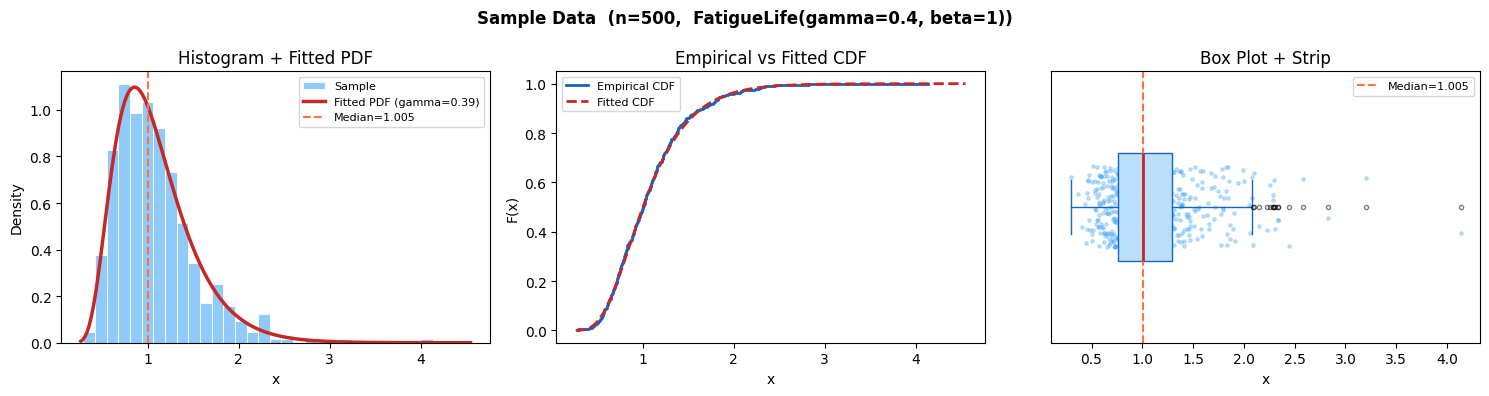

n=500  mean=1.0810  median=1.0051  std=0.4480  skew=1.6206  kurtosis=5.3841


In [3]:
# Sample data plots — Birnbaum-Saunders/FatigueLife(gamma=0.4, beta=1)
np.random.seed(42)
sample_d = stats.fatiguelife.rvs(c=0.4, scale=1, size=500)
c_hat, loc_hat, scale_hat = stats.fatiguelife.fit(sample_d, floc=0)
x_fit = np.linspace(sample_d.min() * 0.9, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  FatigueLife(gamma=0.4, beta=1))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.fatiguelife(c_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (gamma={c_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.fatiguelife(c_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Physical model** | Derived from crack growth: failure when accumulated damage exceeds threshold |
| **Shape $\gamma$** | Small $\gamma$ → symmetric; large $\gamma$ → heavy right tail |
| **vs Weibull** | Both model failure times; Birnbaum-Saunders has a physical crack-growth justification |
| **vs Lognormal** | Similar shape; both model products of small incremental damage |
| **Scale $\beta$** | Median of the distribution (when $\mu=0$) |
| **Use** | Fatigue life of metals, composites; S-N curve (stress vs cycles to failure) modeling |
